In [2]:
%matplotlib inline

import intake
from access_nri_intake.source.builders import AccessOm2Builder

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean.cm as cmocean
import glob
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.path as mpath
import matplotlib.colors as col
#import matplotlib.pyplot as pyplot
import matplotlib.pyplot as plt # to generate plots

from netCDF4 import Dataset
from pint import application_registry as ureg
import pint_xarray
import xarray as xr
import xesmf as xe
import cmocean as cm

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client
from collections import OrderedDict

figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

In [3]:
client = Client(threads_per_worker=1, memory_limit=0, silence_logs=logging.ERROR)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39299,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44765,Total threads: 1
Dashboard: /proxy/33443/status,Memory: 0 B
Nanny: tcp://127.0.0.1:34399,


### Cosima-cookbook section (out-of-date):

In [3]:
# CONTROL
session_name = '/g/data/v45/wf4500/databases/gdata_01deg_jra55v13_ryf9091_DSW.db'
master_session = cc.database.create_session(session_name)
#experiment
control = '01deg_jra55v13_ryf9091_DSW'

#PERTURBATIONS
session_name = '/g/data/ik11/databases/basal_melt_MOM5.db'
basal_melt_session = cc.database.create_session(session_name)
#experiments
basal_gade_woa_newname = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'
basal_nogade_woa = '01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'
basal_gade_brine = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'

In [6]:
# topography data for plotting:
ht = cc.querying.getvar(control, 'ht', master_session, n=1)#.sel(yt_ocean=lat_slice)
land_mask = np.squeeze(ht.values)*0
land_mask[np.isnan(land_mask)] = 1
land_mask = np.where(land_mask==1, land_mask,np.nan)
land_mask_masked = np.ma.masked_where((land_mask==0), land_mask)
# make land go all the way to -90S:
#land_mask_lat = ht.yt_ocean.values
#land_mask_lat[0] = -90


### Intake Catalog:

In [5]:
# add experiments to my own intake:

# - control:
path_ctrl = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade: GPC023 (Basal_LH)   
path_BG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'

### SOFIA meltwater perturbation expts:
# - control:
path_ctrl_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126"

# - basal No Gade: GPC029 (Basal)   
path_noBG_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126"

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126"

path_ctrl_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_antwater"
path_BGB_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_antwater"

# new control runs with Gadel line:
path_ctrl_BG = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_Gade"
path_ctrl_BG_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_Gade_sofia_antwater"
path_ctrl_antwater_BG = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_antwater_Gade"


Buil datastore:

In [6]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl
).build()

builder.save(
    name="DSW_control", 
    description="Datastore for ACCESS-OM2 ryf9091 DSW control",
)


builder = AccessOm2Builder(
    path=path_noBG
).build()

builder.save(
    name="Basal", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal",
)

builder = AccessOm2Builder(
    path=path_BG,
).build()

builder.save(
    name="Basal_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH",
)

builder = AccessOm2Builder(
    path=path_BGB,
).build()

builder.save(
    name="Basal_LH_Brine", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
)


builder = AccessOm2Builder(
    path=path_ctrl_sofia
).build()

builder.save(
    name="DSW_control_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA control (mbath21)",
)


builder = AccessOm2Builder(
    path=path_noBG_sofia
).build()

builder.save(
    name="Basal_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal rep.",
)


builder = AccessOm2Builder(
    path=path_BGB_sofia
).build()

builder.save(
    name="Basal_LH_Brine_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal_LH_Brine rep.",
)


builder = AccessOm2Builder(
    path=path_ctrl_antwater
).build()

builder.save(
    name="DSW_control_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater control (mbath21)",
)


builder = AccessOm2Builder(
    path=path_BGB_antwater
).build()

builder.save(
    name="Basal_LH_Brine_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater Basal_LH_Brine",
)


builder = AccessOm2Builder(
    path=path_ctrl_BG
).build()

builder.save(
    name="DSW_control_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 control + Antwater applying Gade line (all runoff)",
)


builder = AccessOm2Builder(
    path=path_ctrl_BG_antwater
).build()

builder.save(
    name="DSW_control_LH_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 control applying Gade line only for Antwater anomaly",
)


builder = AccessOm2Builder(
    path=path_ctrl_antwater_BG
).build()

builder.save(
    name="DSW_control_antwater_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 control applying Gade line only for Antwater anomaly",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_antwater.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine_antwater.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_LH.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_LH_antwater.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_antwater_LH

In [8]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_noBG = intake.open_esm_datastore(
    "./Basal.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BG = intake.open_esm_datastore(
    "./Basal_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_sofia = intake.open_esm_datastore(
    "./DSW_control_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important 
)

cat_noBG_sofia = intake.open_esm_datastore(
    "./Basal_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BGB_sofia = intake.open_esm_datastore(
    "./Basal_LH_Brine_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_antwater = intake.open_esm_datastore(
    "./DSW_control_antwater.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BGB_antwater = intake.open_esm_datastore(
    "./Basal_LH_Brine_antwater.json",
    columns_with_iterables=["variable"] # This is important
)

cat_SSStest = intake.open_esm_datastore(
    "./DSW_control_noSSSrest.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrlBG = intake.open_esm_datastore(
    "./DSW_control_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrlBG_antwater = intake.open_esm_datastore(
    "./DSW_control_LH_antwater.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrl_antwater_BG = intake.open_esm_datastore(
    "./DSW_control_antwater_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

### Define colobars and experiments color/names etc:

In [9]:
def colorbar_horz(cb, axes, label):
    fs = 10
    cbaxes = fig.add_axes(axes)
    cbar = plt.colorbar(cb, cax = cbaxes, orientation = 'horizontal',extend = 'max')
    cbar.set_label(label,fontsize=fs+2,labelpad=2)
    cbar.ax.tick_params(labelsize=fs)
    return cbar


In [10]:
def colorbar_vert(cb, axes, label):
    fs = 10
    cbaxes = fig.add_axes(axes)
    cbar = plt.colorbar(cb, cax=cbaxes, orientation='vertical', extend = 'both')
    cbar.set_label(label,fontsize=fs+2,labelpad=2)
    cbar.ax.tick_params(labelsize=fs)
    return cbar
 

In [14]:
%%time
# Make sure these match the available restarts:
start_time = '1907-01-01'
end_time = '1910-01-01'
lat_slice  = slice(-80,-30)

CPU times: user 3 μs, sys: 20 μs, total: 23 μs
Wall time: 27.9 μs


In [145]:
### version using intake:
u_control = cat.search(variable='u', frequency="1mon").to_dask(decode_timedelta=True)
u_control = u_control.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').load()

#Basal
u_basal = cat_noBG.search(variable='u', frequency="1mon").to_dask(decode_timedelta=True)
u_basal = u_basal.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').load()

#Basal_LH
u_lh = cat_BG.search(variable='u', frequency="1mon").to_dask(decode_timedelta=True)
u_lh = u_lh.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').load()

#Basal_LH_brine
u_lh_brine = cat_BGB.search(variable='u', frequency="1mon").to_dask(decode_timedelta=True)
u_lh_brine = u_lh_brine.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').load()

In [343]:
# read model layer thickness to use bottom partial cells in the figure:
dzt = cat.search(variable='dzt').to_dask()
dzt = dzt.rename({'xt_ocean': 'xu_ocean','yt_ocean': 'yu_ocean'})

#- t-grid -> u-grid
# dztu = 0.5 * (dzt +dzt.shift(xt_ocean=-1))
# dzu = 0.5 * (dztu +dztu.shift(yt_ocean=-1))
# dzu = dzu.rename({'xt_ocean': 'xu_ocean','yt_ocean': 'yu_ocean'})

# I'm assuming dzt ~ dzu for simplicity:
dzu_section = dzt.sel(xu_ocean=-120, method='nearest') \
                .sel(yu_ocean=slice(-73, -71.55)) \
                .sel(st_ocean=slice(0, 1200)) \
                .mean('time') \
                .load()


In [345]:
dzu_section['xu_ocean'] = u_control.xu_ocean
dzu_section['yu_ocean'] = u_control.yu_ocean

In [386]:
z_interfaces = dzu_section.cumsum(dim='st_ocean')
Z=z_interfaces

In [388]:
# Horizontal coordinate (centers → ok to use directly)
Y = u_control.yu_ocean.broadcast_like(u_control)


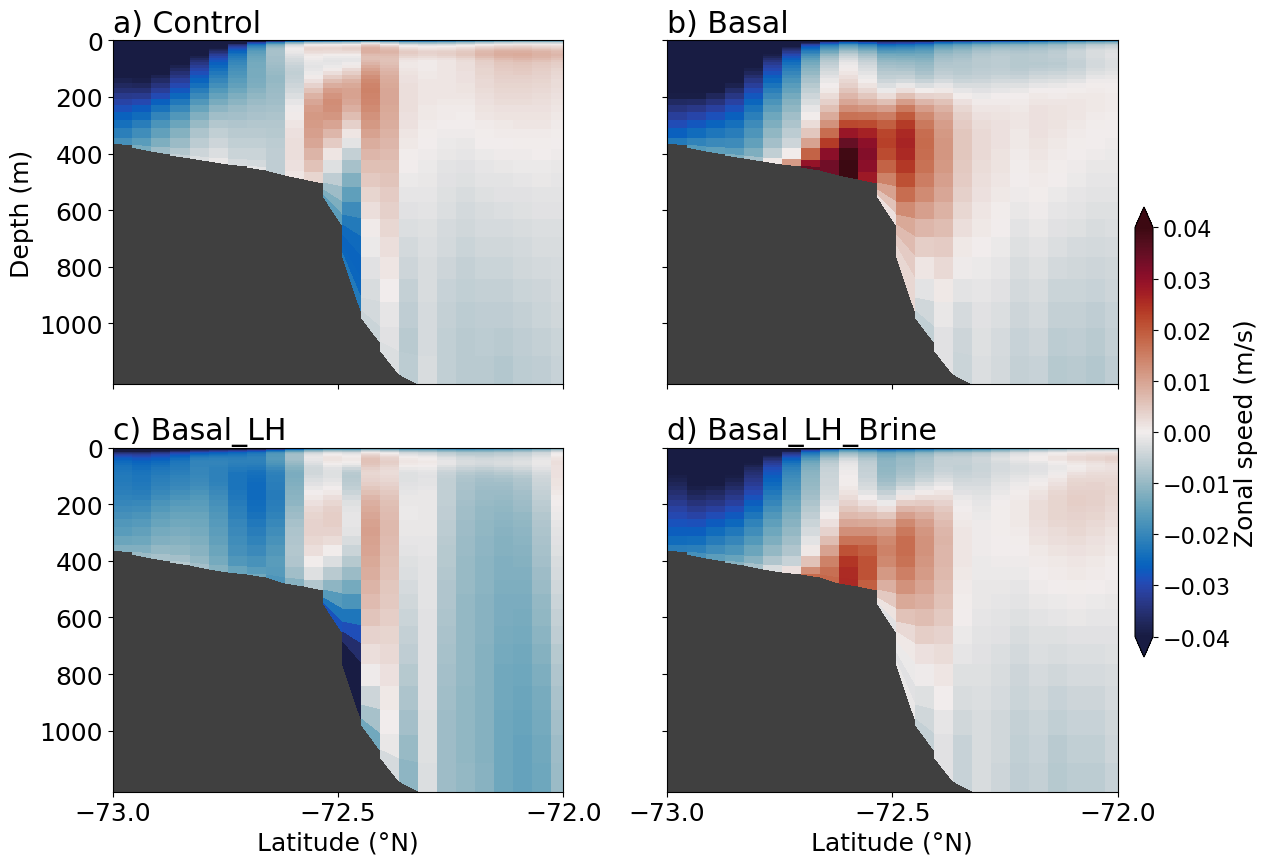

In [393]:
plt.rcParams['font.size'] = 18

fig = plt.figure(figsize=(12, 9))
x_formatter = mpl.ticker.ScalarFormatter(useOffset=False)


clev = np.arange(-.035,.035,.005)
tick_lvls = np.arange(-.035, .04, .01)

var1 = u_control.u
plt.subplot(2,2,1)
plt.gca().patch.set_color('.25')
p1=plt.pcolormesh(Y,Z.dzt,var1,vmin=-0.04, vmax=0.04,cmap=cm.cm.balance)
plt.gca().invert_yaxis()
plt.ylabel('Depth (m)',fontsize=18)
plt.xticks([-73, -72.5, -72],labels=[])
plt.yticks([0,200,400,600,800,1000])
plt.title('a) Control',loc='left')
plt.xlim(-73,-72)

var1 = u_basal.u
plt.subplot(2,2,2)
plt.gca().patch.set_color('.25')
p1=plt.pcolormesh(Y,Z.dzt,var1,vmin=-0.04, vmax=0.04,cmap=cm.cm.balance)
plt.gca().invert_yaxis()
plt.xticks([-73, -72.5, -72],labels=[])
plt.yticks([0,200,400,600,800,1000],labels=[])
plt.title('b) Basal',loc='left')
plt.xlim(-73,-72)

var1 = u_lh.u
plt.subplot(2,2,3)
plt.gca().patch.set_color('.25')
p1=plt.pcolormesh(Y,Z.dzt,var1,vmin=-0.04, vmax=0.04,cmap=cm.cm.balance)
plt.gca().invert_yaxis()
plt.xticks([-73, -72.5, -72])
plt.yticks([0,200,400,600,800,1000])
plt.xlabel('Latitude (\u00b0N)')
plt.title('c) Basal_LH',loc='left')
plt.xlim(-73,-72)

var1 = u_lh_brine.u
plt.subplot(2,2,4)
plt.gca().patch.set_color('.25')
p1=plt.pcolormesh(Y,Z.dzt,var1,vmin=-0.04, vmax=0.04,cmap=cm.cm.balance)
plt.gca().invert_yaxis()
plt.xticks([-73, -72.5, -72])
plt.xlabel('Latitude (\u00b0N)')
plt.yticks([0,200,400,600,800,1000],labels=[])
plt.title('d) Basal_LH_Brine',loc='left')
plt.xlim(-73,-72)

# colorbar:
cbaxes = fig.add_axes([.96,.25, 0.015, 0.5])
cbar = plt.colorbar(p1, cax=cbaxes, orientation='vertical', extend = 'both')
cbar.set_label('Zonal speed (m/s)',fontsize=18,labelpad=2)
cbar.ax.tick_params(labelsize=16)

fig.tight_layout()

of = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/undercurrent_120E.png'
fig.savefig(of,dpi=300,bbox_inches='tight')

### End of script modified by Fabio

Date: 02/6/2026

Below there are a couple other analyses that Paul did; it likely needs to be adjust to use the intake catalog, as Paul was using cosima-cookbook previously.

(36, 75, 142, 300)
(36, 75, 142, 300)
(36, 75, 142, 300)
(36, 75, 142, 300)


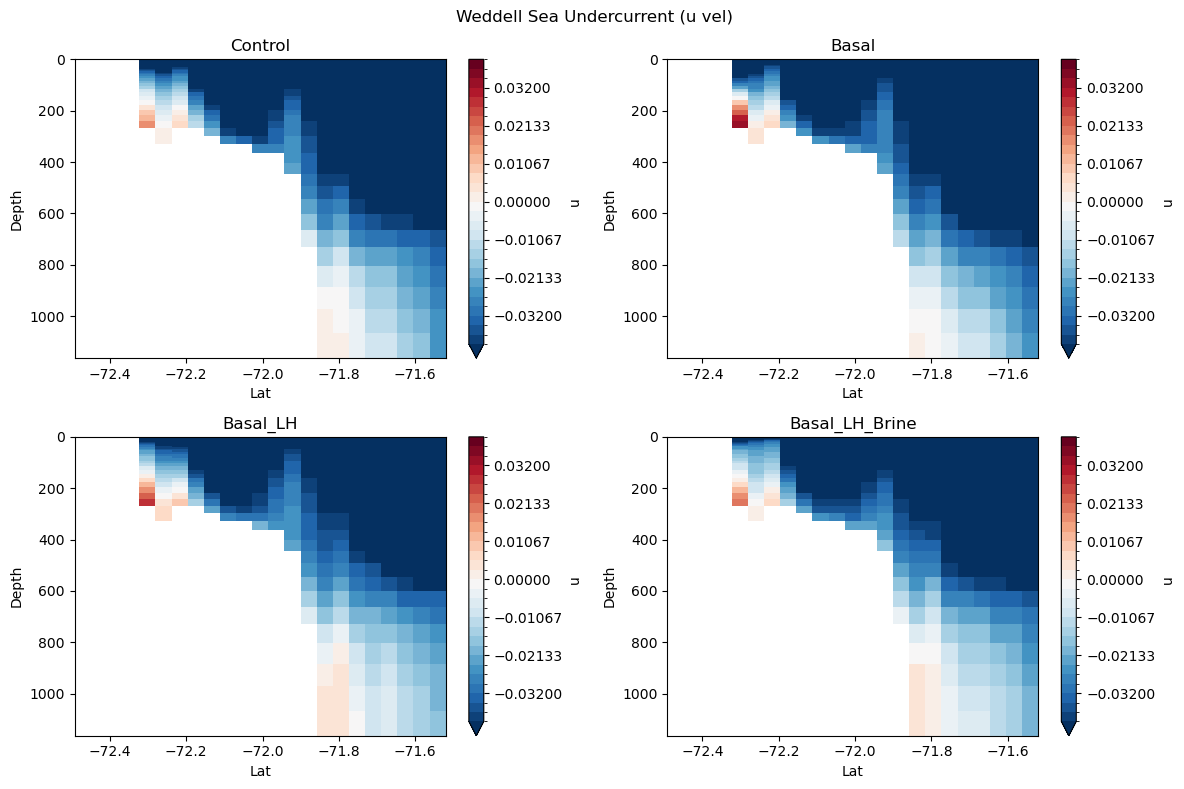

In [37]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

#control
u = cc.querying.getvar(control, 'u', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

#Basal
u = cc.querying.getvar(basal_nogade_woa, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,-0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


#Basal_LH_Brine
u = cc.querying.getvar(basal_gade_woa_newname, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


#Basal_LH
u = cc.querying.getvar(basal_gade_brine, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

cnt=-1
for i in range(2):
    for j in range(2):
        cnt=cnt+1
        ax[i,j].invert_yaxis()

        ax[i,j].set_ylabel('Depth')

        ax[i,j].set_xlabel('Lat')

        ax[i,j].set_title(keys[cnt])

plt.suptitle('Weddell Sea Undercurrent (u vel)')
plt.tight_layout()


In [3]:
#session_name = '/g/data/v45/wf4500/databases/gdata_01deg_jra55v13_ryf9091_DSW.db'
control = '01deg_jra55v13_ryf9091_DSW'
master_session = cc.database.create_session(session_name)

session_name = '/g/data/ik11/databases/basal_melt_MOM5.db'
basal_melt_session = cc.database.create_session(session_name)
      
# temperature of meltwater using Gade line:
basal_gade = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'
basal_gade_icb = '01deg_jra55v13_ryf9091_DSW_BasalGade_YesIcb'
basal_nogade = '01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'
basal_gade_brine = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'


In [4]:
%%time
# Make sure these match the available restarts:
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,0)

CPU times: user 9 µs, sys: 0 ns, total: 9 µs
Wall time: 19.3 µs


In [5]:
#plot amundsen sea undercurrent

(12, 75, 142, 350)
(12, 75, 142, 350)
(12, 75, 142, 350)
(12, 75, 142, 350)


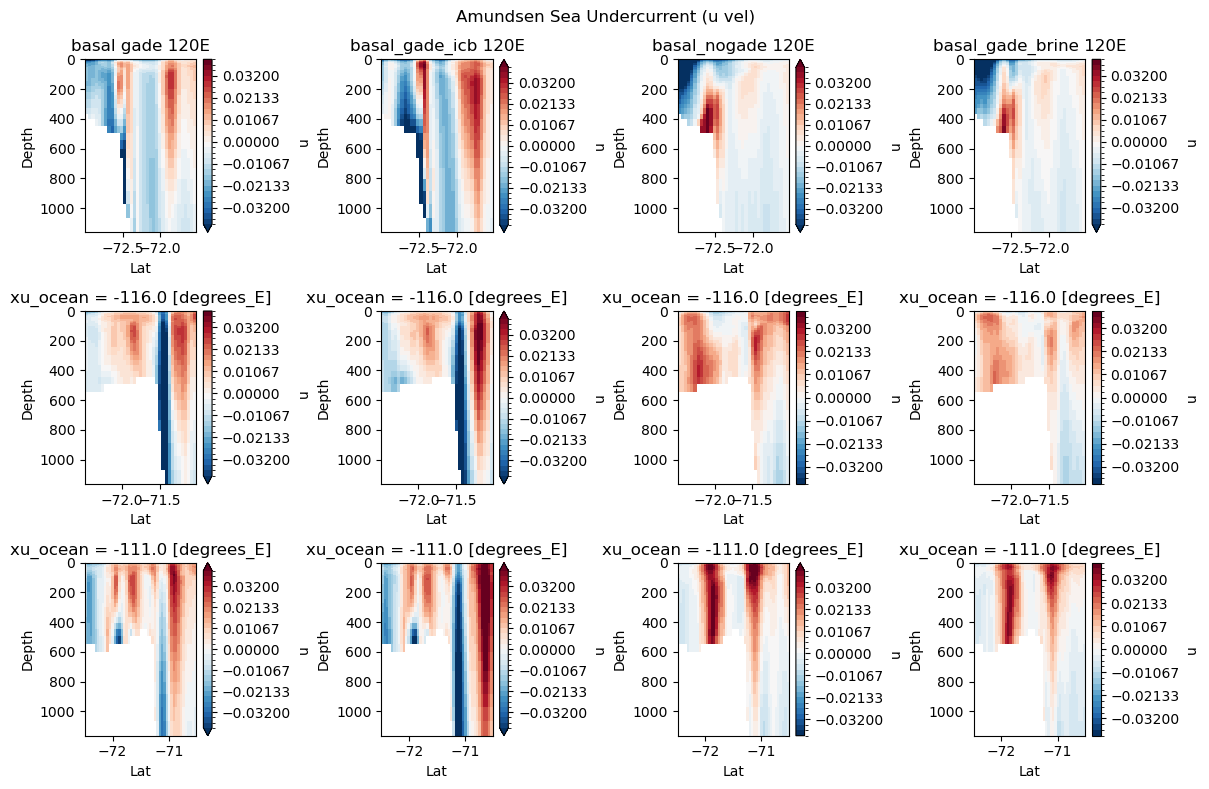

In [6]:
# Make sure these match the available restarts:
start_time='1909-01-01'
end_time='1909-12-31'


fig, ax = plt.subplots(3,4, figsize=(12,8))

 
u = cc.querying.getvar(basal_gade, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-130,-95)).load()
print(u.shape)

u.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -116,method='nearest').sel(yu_ocean = slice(-72.5,-71)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -111,method='nearest').sel(yu_ocean = slice(-72.5,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


u = cc.querying.getvar(basal_gade_icb, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-130,-95)).load()
print(u.shape)

u.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -116,method='nearest').sel(yu_ocean = slice(-72.5,-71)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -111,method='nearest').sel(yu_ocean = slice(-72.5,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u = cc.querying.getvar(basal_nogade, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-130,-95)).load()
print(u.shape)

u.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -116,method='nearest').sel(yu_ocean = slice(-72.5,-71)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -111,method='nearest').sel(yu_ocean = slice(-72.5,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u = cc.querying.getvar(basal_gade_brine, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-130,-95)).load()
print(u.shape)

u.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -116,method='nearest').sel(yu_ocean = slice(-72.5,-71)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -111,method='nearest').sel(yu_ocean = slice(-72.5,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


tits=['basal gade 120E', 'basal_gade_icb 120E','basal_nogade 120E', 'basal_gade_brine 120E']

for i in range(3):
    for j in range(4):

        ax[i,j].invert_yaxis()

        ax[i,j].set_ylabel('Depth')

        ax[i,j].set_xlabel('Lat')

        if i==0:
            ax[i,j].set_title(tits[j])    

plt.suptitle('Amundsen Sea Undercurrent (u vel)')
plt.tight_layout()


In [7]:
ax

array([[<Axes: title={'center': 'basal gade 120E'}, xlabel='Lat', ylabel='Depth'>,
        <Axes: title={'center': 'basal_gade_icb 120E'}, xlabel='Lat', ylabel='Depth'>,
        <Axes: title={'center': 'basal_nogade 120E'}, xlabel='Lat', ylabel='Depth'>,
        <Axes: title={'center': 'basal_gade_brine 120E'}, xlabel='Lat', ylabel='Depth'>],
       [<Axes: title={'center': 'xu_ocean = -116.0 [degrees_E]'}, xlabel='Lat', ylabel='Depth'>,
        <Axes: title={'center': 'xu_ocean = -116.0 [degrees_E]'}, xlabel='Lat', ylabel='Depth'>,
        <Axes: title={'center': 'xu_ocean = -116.0 [degrees_E]'}, xlabel='Lat', ylabel='Depth'>,
        <Axes: title={'center': 'xu_ocean = -116.0 [degrees_E]'}, xlabel='Lat', ylabel='Depth'>],
       [<Axes: title={'center': 'xu_ocean = -111.0 [degrees_E]'}, xlabel='Lat', ylabel='Depth'>,
        <Axes: title={'center': 'xu_ocean = -111.0 [degrees_E]'}, xlabel='Lat', ylabel='Depth'>,
        <Axes: title={'center': 'xu_ocean = -111.0 [degrees_E]'}, xlabel

(12, 75, 142, 350)


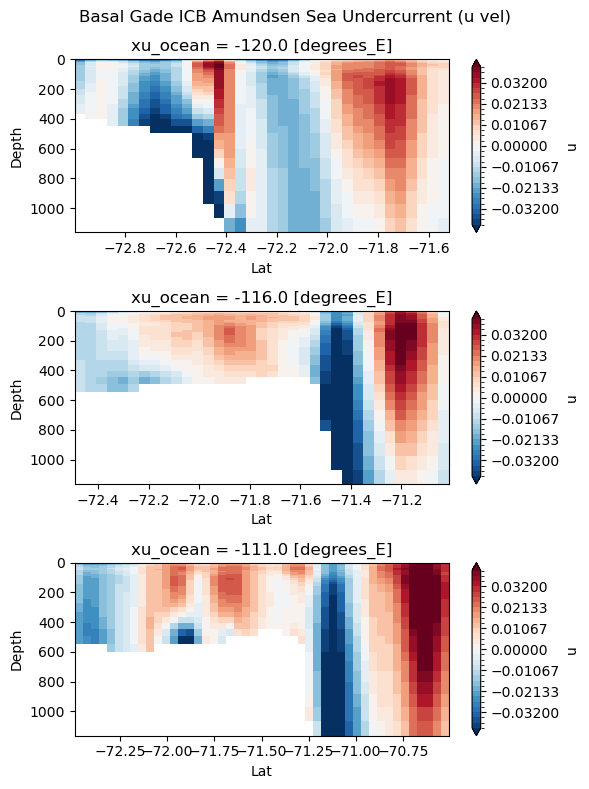

In [8]:
# Make sure these match the available restarts:
start_time='1909-01-01'
end_time='1909-12-31'

u = cc.querying.getvar(basal_gade_icb, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-130,-95)).load()
print(u.shape)
 

fig, ax = plt.subplots(3,1, figsize=(6,8))

 

u.sel(xu_ocean = -120,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -116,method='nearest').sel(yu_ocean = slice(-72.5,-71)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -111,method='nearest').sel(yu_ocean = slice(-72.5,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

 

for i in range(3):

    ax[i].invert_yaxis()

    ax[i].set_ylabel('Depth')

    ax[i].set_xlabel('Lat')

plt.suptitle('Basal Gade ICB Amundsen Sea Undercurrent (u vel)')
plt.tight_layout()

In [9]:
print(u.time)

<xarray.DataArray 'time' (time: 12)>
array([cftime.DatetimeNoLeap(1909, 1, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 3, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 4, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 5, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 6, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 7, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 8, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 9, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 10, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 11, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 12, 16, 12, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time)

(12, 75, 142, 300)
(12, 75, 142, 300)
(12, 75, 142, 300)
(12, 75, 142, 300)


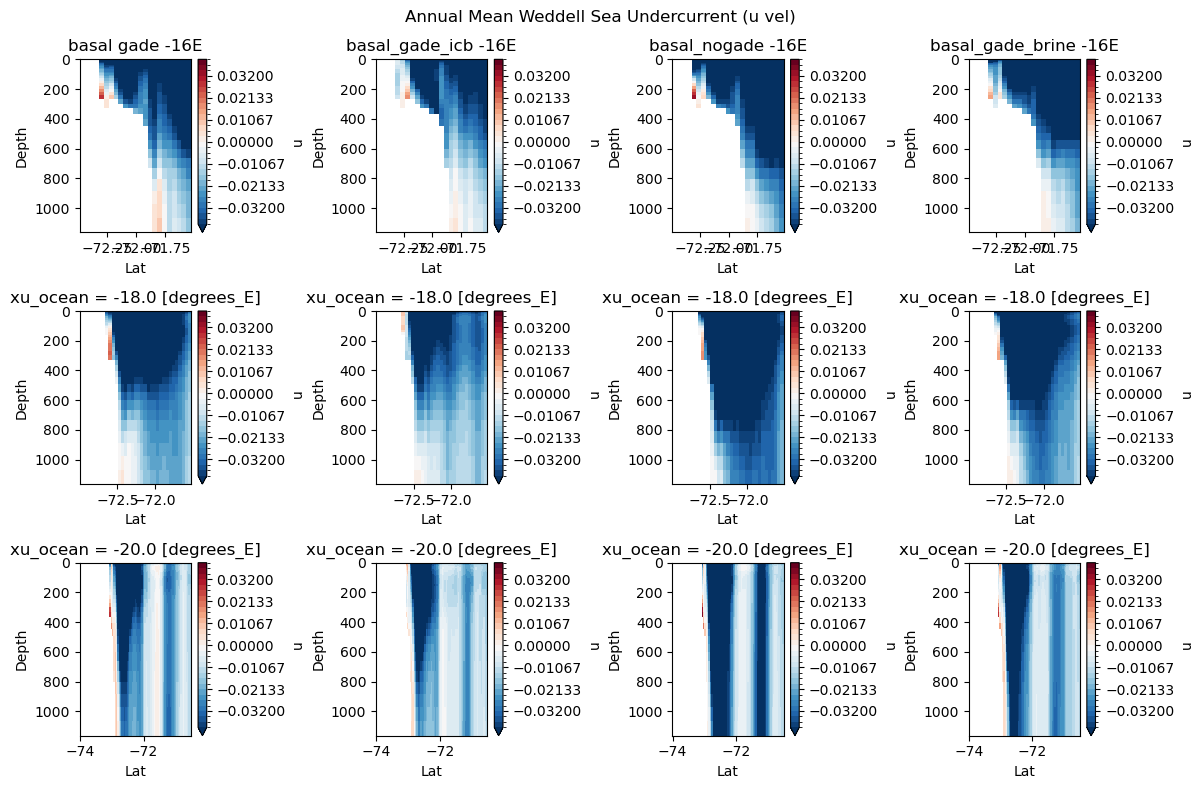

In [27]:
#plot Weddell Sea undercurrent (seasonal varying ... look in Feb.) https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2010GL043603

# Make sure these match the available restarts:
start_time='1909-01-01'
end_time='1909-12-31'


fig, ax = plt.subplots(3,4, figsize=(12,8))

 
u = cc.querying.getvar(basal_gade, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -18,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -20,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


u = cc.querying.getvar(basal_gade_icb, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -18,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -20,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u = cc.querying.getvar(basal_nogade, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -18,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -20,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u = cc.querying.getvar(basal_gade_brine, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -18,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -20,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


tits=['basal gade -16E', 'basal_gade_icb -16E','basal_nogade -16E', 'basal_gade_brine -16E']

for i in range(3):
    for j in range(4):

        ax[i,j].invert_yaxis()

        ax[i,j].set_ylabel('Depth')

        ax[i,j].set_xlabel('Lat')

        if i==0:
            ax[i,j].set_title(tits[j])    

plt.suptitle('Annual Mean Weddell Sea Undercurrent (u vel)')
plt.tight_layout()


(3, 75, 142, 300)
(3, 75, 142, 300)
(3, 75, 142, 300)
(3, 75, 142, 300)


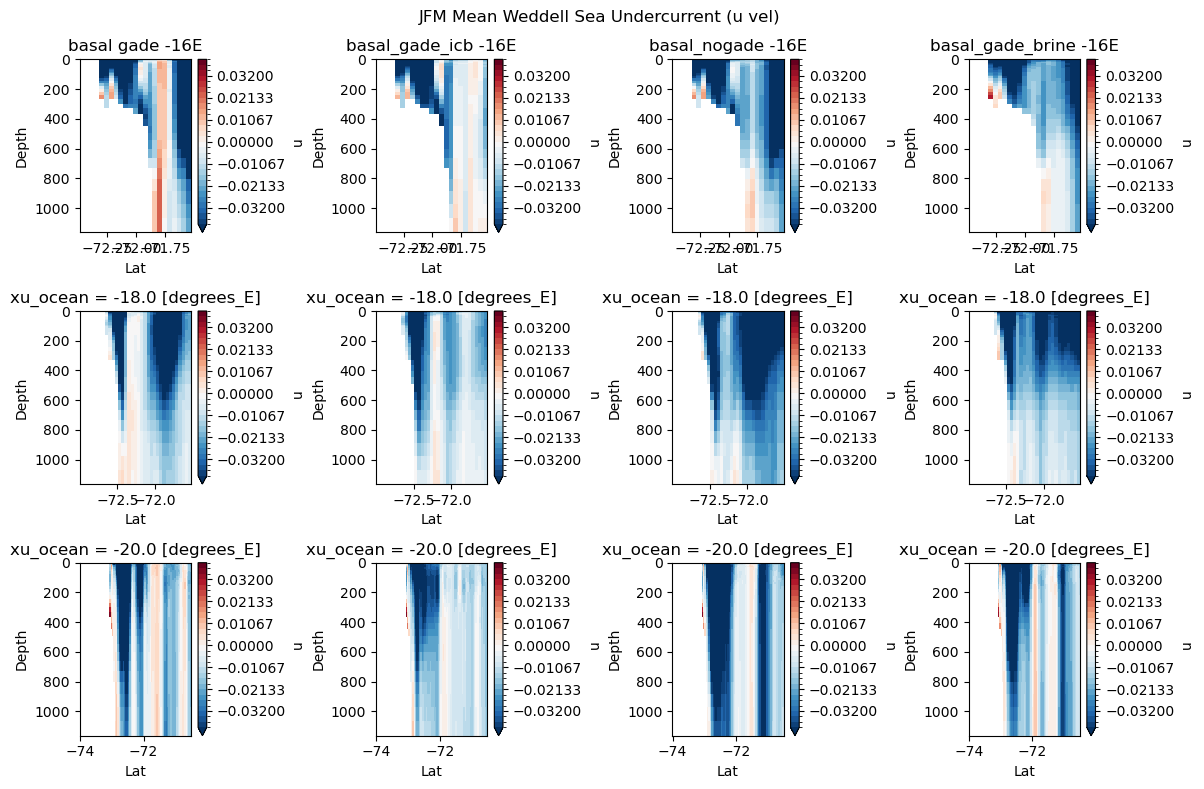

In [28]:
#plot Weddell Sea undercurrent (seasonal varying ... look in Feb.) https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2010GL043603

# Make sure these match the available restarts:
start_time='1909-01-01'
end_time='1909-03-31'


fig, ax = plt.subplots(3,4, figsize=(12,8))

 
u = cc.querying.getvar(basal_gade, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -18,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -20,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


u = cc.querying.getvar(basal_gade_icb, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -18,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -20,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u = cc.querying.getvar(basal_nogade, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -18,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -20,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u = cc.querying.getvar(basal_gade_brine, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u.sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[0,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -18,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[1,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u.sel(xu_ocean = -20,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).mean('time').plot(ax=ax[2,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


tits=['basal gade -16E', 'basal_gade_icb -16E','basal_nogade -16E', 'basal_gade_brine -16E']

for i in range(3):
    for j in range(4):

        ax[i,j].invert_yaxis()

        ax[i,j].set_ylabel('Depth')

        ax[i,j].set_xlabel('Lat')

        if i==0:
            ax[i,j].set_title(tits[j])    

plt.suptitle('JFM Mean Weddell Sea Undercurrent (u vel)')
plt.tight_layout()


(12, 75, 142, 300)
(12, 75, 142, 300)
(12, 75, 142, 300)
(12, 75, 142, 300)


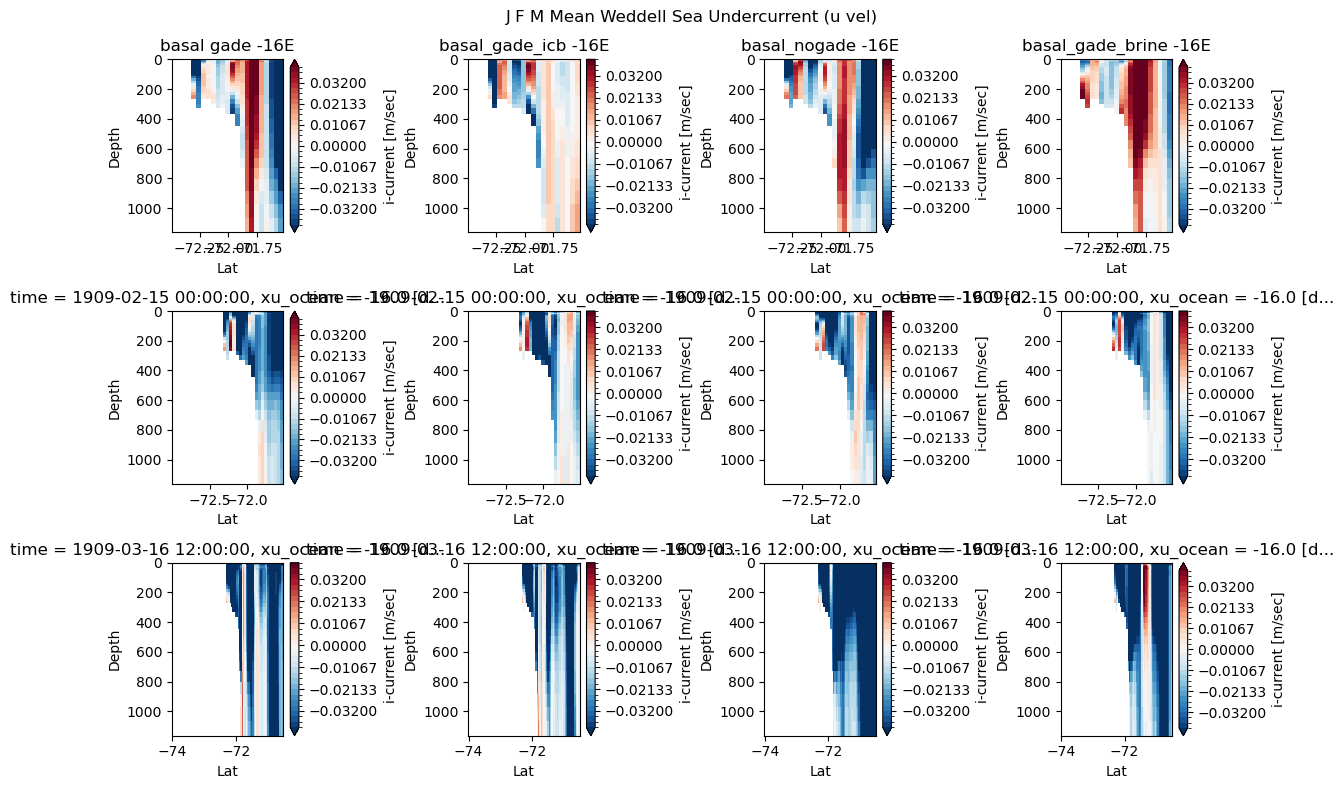

In [26]:
#plot Weddell Sea undercurrent (seasonal varying ... look in Feb.) https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2010GL043603

# Make sure these match the available restarts:
start_time='1909-01-01'
end_time='1909-12-31'


fig, ax = plt.subplots(3,4, figsize=(12,8))

 
u = cc.querying.getvar(basal_gade, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u[0].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[0,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u[1].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[1,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u[2].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[2,0],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


u = cc.querying.getvar(basal_gade_icb, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u[0].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[0,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u[1].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[1,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u[2].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[2,1],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u = cc.querying.getvar(basal_nogade, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u[0].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[0,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u[1].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[1,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u[2].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[2,2],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u = cc.querying.getvar(basal_gade_brine, 'u', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly').sel(time=slice(start_time,end_time)).sel(yu_ocean=slice(-76,-70)).sel(xu_ocean = slice(-30,0)).load()
print(u.shape)

u[0].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-72.5,-71.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[0,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u[1].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-73,-71.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[1,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))

u[2].sel(xu_ocean = -16,method='nearest').sel(yu_ocean = slice(-74,-70.5)).sel(st_ocean = slice(0,1200)).plot(ax=ax[2,3],x='yu_ocean',y='st_ocean',levels=np.linspace(-.04,0.04,31))


tits=['basal gade -16E', 'basal_gade_icb -16E','basal_nogade -16E', 'basal_gade_brine -16E']

for i in range(3):
    for j in range(4):

        ax[i,j].invert_yaxis()

        ax[i,j].set_ylabel('Depth')

        ax[i,j].set_xlabel('Lat')

        if i==0:
            ax[i,j].set_title(tits[j])    

plt.suptitle('J F M Mean Weddell Sea Undercurrent (u vel)')
plt.tight_layout()


In [24]:
print(u.shape)
uu=u[0]
uu.shape

(3, 75, 142, 300)


(75, 142, 300)

In [23]:
u.time

<xarray.DataArray 'time' (time: 3)>
array([cftime.DatetimeNoLeap(1909, 1, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 3, 16, 12, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 1909-01-16 12:00:00 ... 1909-03-16 12:00:00
Attributes:
    long_name:       time
    cartesian_axis:  T
    calendar_type:   NOLEAP
    bounds:          time_bounds

In [10]:
# load moc transports
psi = cc.querying.getvar(basal_gade, 'ty_trans_rho', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly',chunks={'grid_yu_ocean': 100})[0:120,:,:].sel(grid_yu_ocean=lat_slice).resample(time="Y").mean(dim='time')

psi = psi.cf.sum("longitude")

ρ0 = 1025 * ureg.kilogram / ureg.meter**3 # mean density of sea-water
    
# convert mass transport -> volume transport and then convert units -> Sv
psi = (psi / ρ0)/1E6 #.load()

psi = psi.cf.cumsum("vertical") - psi.cf.sum("vertical")
psi.load()

psi.to_netcdf('/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_rhomoc.nc')

In [ ]:
%%time
# Make sure these match the available restarts:
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,0)

# load moc transports
psi = cc.querying.getvar(basal_gade_icb, 'ty_trans_rho', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly',chunks={'grid_yu_ocean': 100})[0:120,:,:].sel(grid_yu_ocean=lat_slice).resample(time="Y").mean(dim='time')

psi = psi.cf.sum("longitude")

ρ0 = 1025 * ureg.kilogram / ureg.meter**3 # mean density of sea-water
    
# convert mass transport -> volume transport and then convert units -> Sv
psi = (psi / ρ0)/1E6 #.load()

psi = psi.cf.cumsum("vertical") - psi.cf.sum("vertical")
psi.load()

psi.to_netcdf('/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_icb_rhomoc.nc')

In [ ]:
%%time
# Make sure these match the available restarts:
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,0)

# load moc transports
psi = cc.querying.getvar(basal_nogade, 'ty_trans_rho', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly',chunks={'grid_yu_ocean': 100})[0:120,:,:].sel(grid_yu_ocean=lat_slice).resample(time="Y").mean(dim='time')

psi = psi.cf.sum("longitude")

ρ0 = 1025 * ureg.kilogram / ureg.meter**3 # mean density of sea-water
    
# convert mass transport -> volume transport and then convert units -> Sv
psi = (psi / ρ0)/1E6 #.load()

psi = psi.cf.cumsum("vertical") - psi.cf.sum("vertical")
psi.load()

psi.to_netcdf('/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_nogade_rhomoc.nc')

In [ ]:
%%time
# Make sure these match the available restarts:
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,0)

# load moc transports
psi = cc.querying.getvar(basal_gade_brine, 'ty_trans_rho', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly',chunks={'grid_yu_ocean': 100})[0:120,:,:].sel(grid_yu_ocean=lat_slice).resample(time="Y").mean(dim='time')

psi = psi.cf.sum("longitude")

ρ0 = 1025 * ureg.kilogram / ureg.meter**3 # mean density of sea-water
    
# convert mass transport -> volume transport and then convert units -> Sv
psi = (psi / ρ0)/1E6 #.load()

psi = psi.cf.cumsum("vertical") - psi.cf.sum("vertical")
psi.load()

psi.to_netcdf('/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_brine_rhomoc.nc')

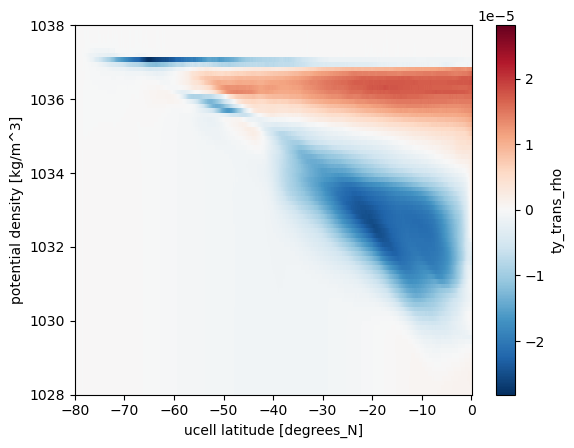

In [47]:
ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_rhomoc.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
psi = ds.ty_trans_rho.load()
psi_avg=psi.mean(dim="time").load()
psi_avg=psi_avg/1E6
psi_avg.plot()

In [51]:
ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_nogade_rhomoc.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode

psi = ds.ty_trans_rho

psi_avg=psi.mean(dim="time").load()
psi_avg=psi_avg

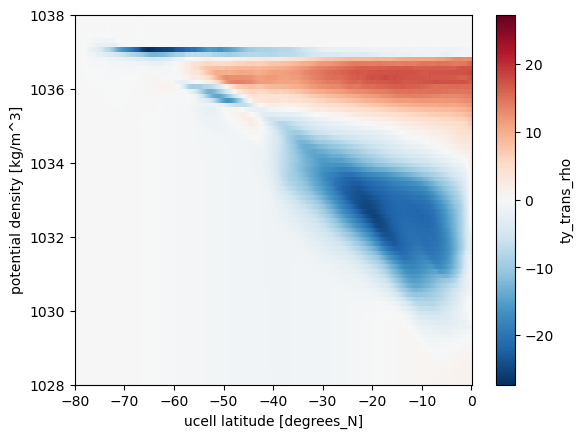

In [52]:
psi_avg.plot()

In [4]:
ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/control_rhomoc.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
c_psi = ds.ty_trans_rho.load()/1E6


ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_rhomoc.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
bg_psi = ds.ty_trans_rho.load()

ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_icb_rhomoc.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
bgicb_psi = ds.ty_trans_rho.load()

ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_nogade_rhomoc.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
bng_psi = ds.ty_trans_rho.load()
 
ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_brine_rhomoc.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
bgb_psi = ds.ty_trans_rho.load()



In [5]:
def levels_and_colorbarticks(max_value):
    """ Return the levels and the colorbarticks for the streamfunction plot.
    It may seem complicated but the truth is we just want to avoid the 0 contour
    so that the plot looks soothing to the eye"""

    levels =  np.hstack((np.arange(-max_value, 0, 2), np.flip(-np.arange(-max_value, 0, 2))))
    cbarticks = np.hstack((np.flip(-np.arange(3, max_value, 6)), np.arange(3, max_value, 6)))

    return levels, cbarticks

In [17]:
bgb_psi.shape

(10, 80, 1219)

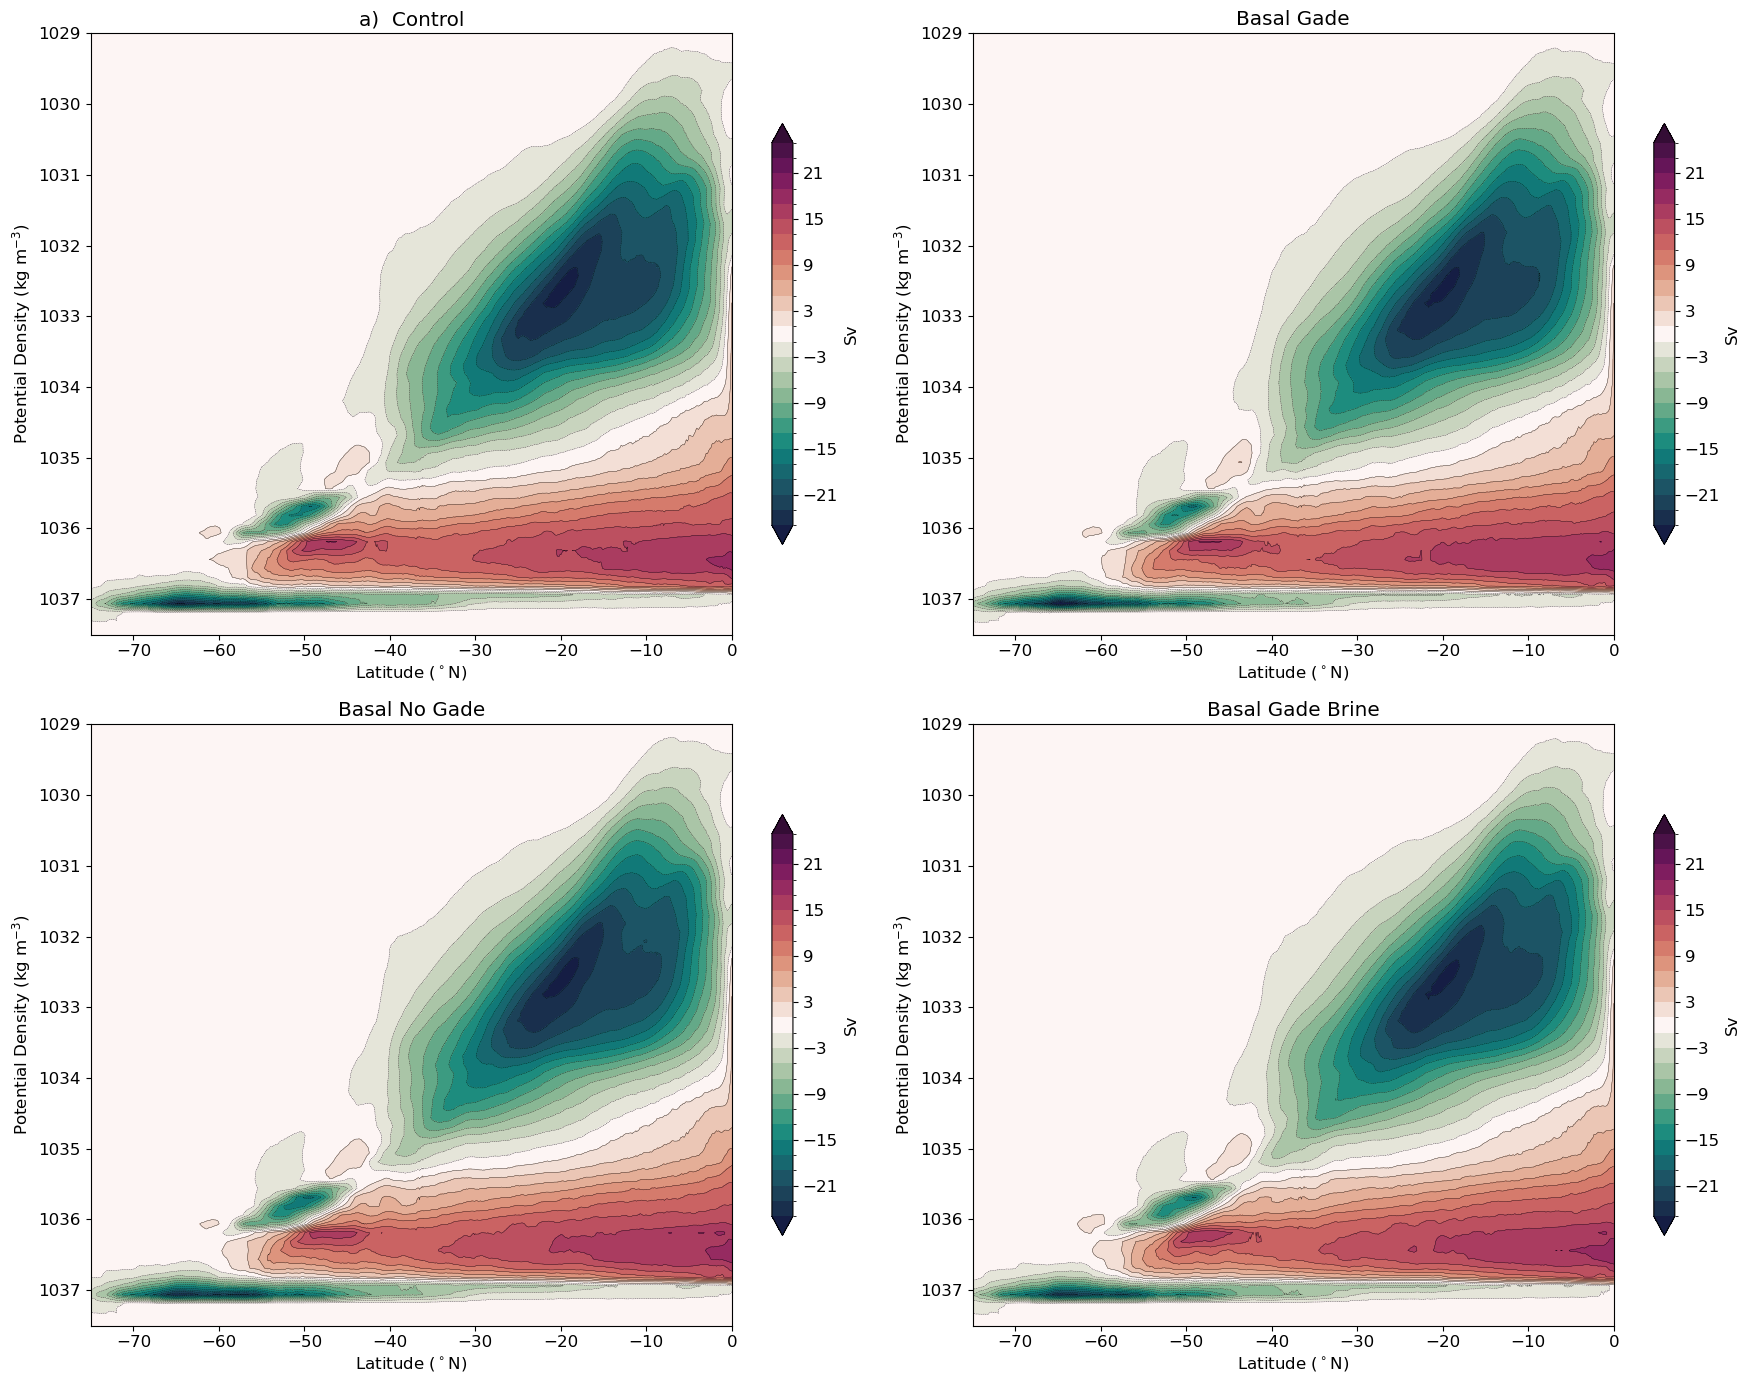

In [11]:
plt.rcParams['font.size'] = 12
fig, axes = plt.subplots(4,2, figsize=(18,14))
plt.subplots_adjust(wspace=0.05, hspace=0.06)

#plt.figure(figsize(12.5,12.5))
#x_formatter = matplotlib.ticker.ScalarFormatter(useOffset=False)

plt.subplot(2,2,1)
max_psi = 25 # Sv
levels, cbarticks = levels_and_colorbarticks(max_psi)

c_psi_avg=c_psi[7:10,:,:].mean(dim="time").load()

c_psi_avg.plot.contourf(levels=levels,
                      cmap=cm.cm.curl,
                      extend='both',
                      cbar_kwargs={'shrink': 0.7, 'label': 'Sv', 'ticks': cbarticks})

c_psi_avg.plot.contour(levels=levels,
                     colors='k',
                     linewidths=0.25)

plt.gca().invert_yaxis()

plt.ylim((1037.5, 1029))
plt.ylabel('Potential Density (kg m$^{-3}$)')
plt.xlabel('Latitude ($^\circ$N)')
plt.xlim([-75, 0])
plt.title(f'a)  Control');

plt.subplot(2,2,2)
max_psi = 25 # Sv
levels, cbarticks = levels_and_colorbarticks(max_psi)

bg_psi_avg=bg_psi[7:10,:,:].mean(dim="time").load()

bg_psi_avg.plot.contourf(levels=levels,
                      cmap=cm.cm.curl,
                      extend='both',
                      cbar_kwargs={'shrink': 0.7, 'label': 'Sv', 'ticks': cbarticks})

bg_psi_avg.plot.contour(levels=levels,
                     colors='k',
                     linewidths=0.25)

plt.gca().invert_yaxis()

plt.ylim((1037.5, 1029))
plt.ylabel('Potential Density (kg m$^{-3}$)')
plt.xlabel('Latitude ($^\circ$N)')
plt.xlim([-75, 0])
plt.title(f'Basal Gade');

plt.subplot(2,2,3)
max_psi = 25 # Sv
levels, cbarticks = levels_and_colorbarticks(max_psi)

bng_psi_avg=bng_psi[7:10,:,:].mean(dim="time").load()

bng_psi_avg.plot.contourf(levels=levels,
                      cmap=cm.cm.curl,
                      extend='both',
                      cbar_kwargs={'shrink': 0.7, 'label': 'Sv', 'ticks': cbarticks})

bng_psi_avg.plot.contour(levels=levels,
                     colors='k',
                     linewidths=0.25)

plt.gca().invert_yaxis()

plt.ylim((1037.5, 1029))
plt.ylabel('Potential Density (kg m$^{-3}$)')
plt.xlabel('Latitude ($^\circ$N)')
plt.xlim([-75, 0])
plt.title(f'Basal No Gade');

plt.subplot(2,2,4)
max_psi = 25 # Sv
levels, cbarticks = levels_and_colorbarticks(max_psi)

bgb_psi_avg=bgb_psi[7:10,:,:].mean(dim="time").load()

bgb_psi_avg.plot.contourf(levels=levels,
                      cmap=cm.cm.curl,
                      extend='both',
                      cbar_kwargs={'shrink': 0.7, 'label': 'Sv', 'ticks': cbarticks})

bgb_psi_avg.plot.contour(levels=levels,
                     colors='k',
                     linewidths=0.25)

plt.gca().invert_yaxis()

plt.ylim((1037.5, 1029))
plt.ylabel('Potential Density (kg m$^{-3}$)')
plt.xlabel('Latitude ($^\circ$N)')
plt.xlim([-75, 0])
plt.title(f'Basal Gade Brine');

plt.tight_layout()

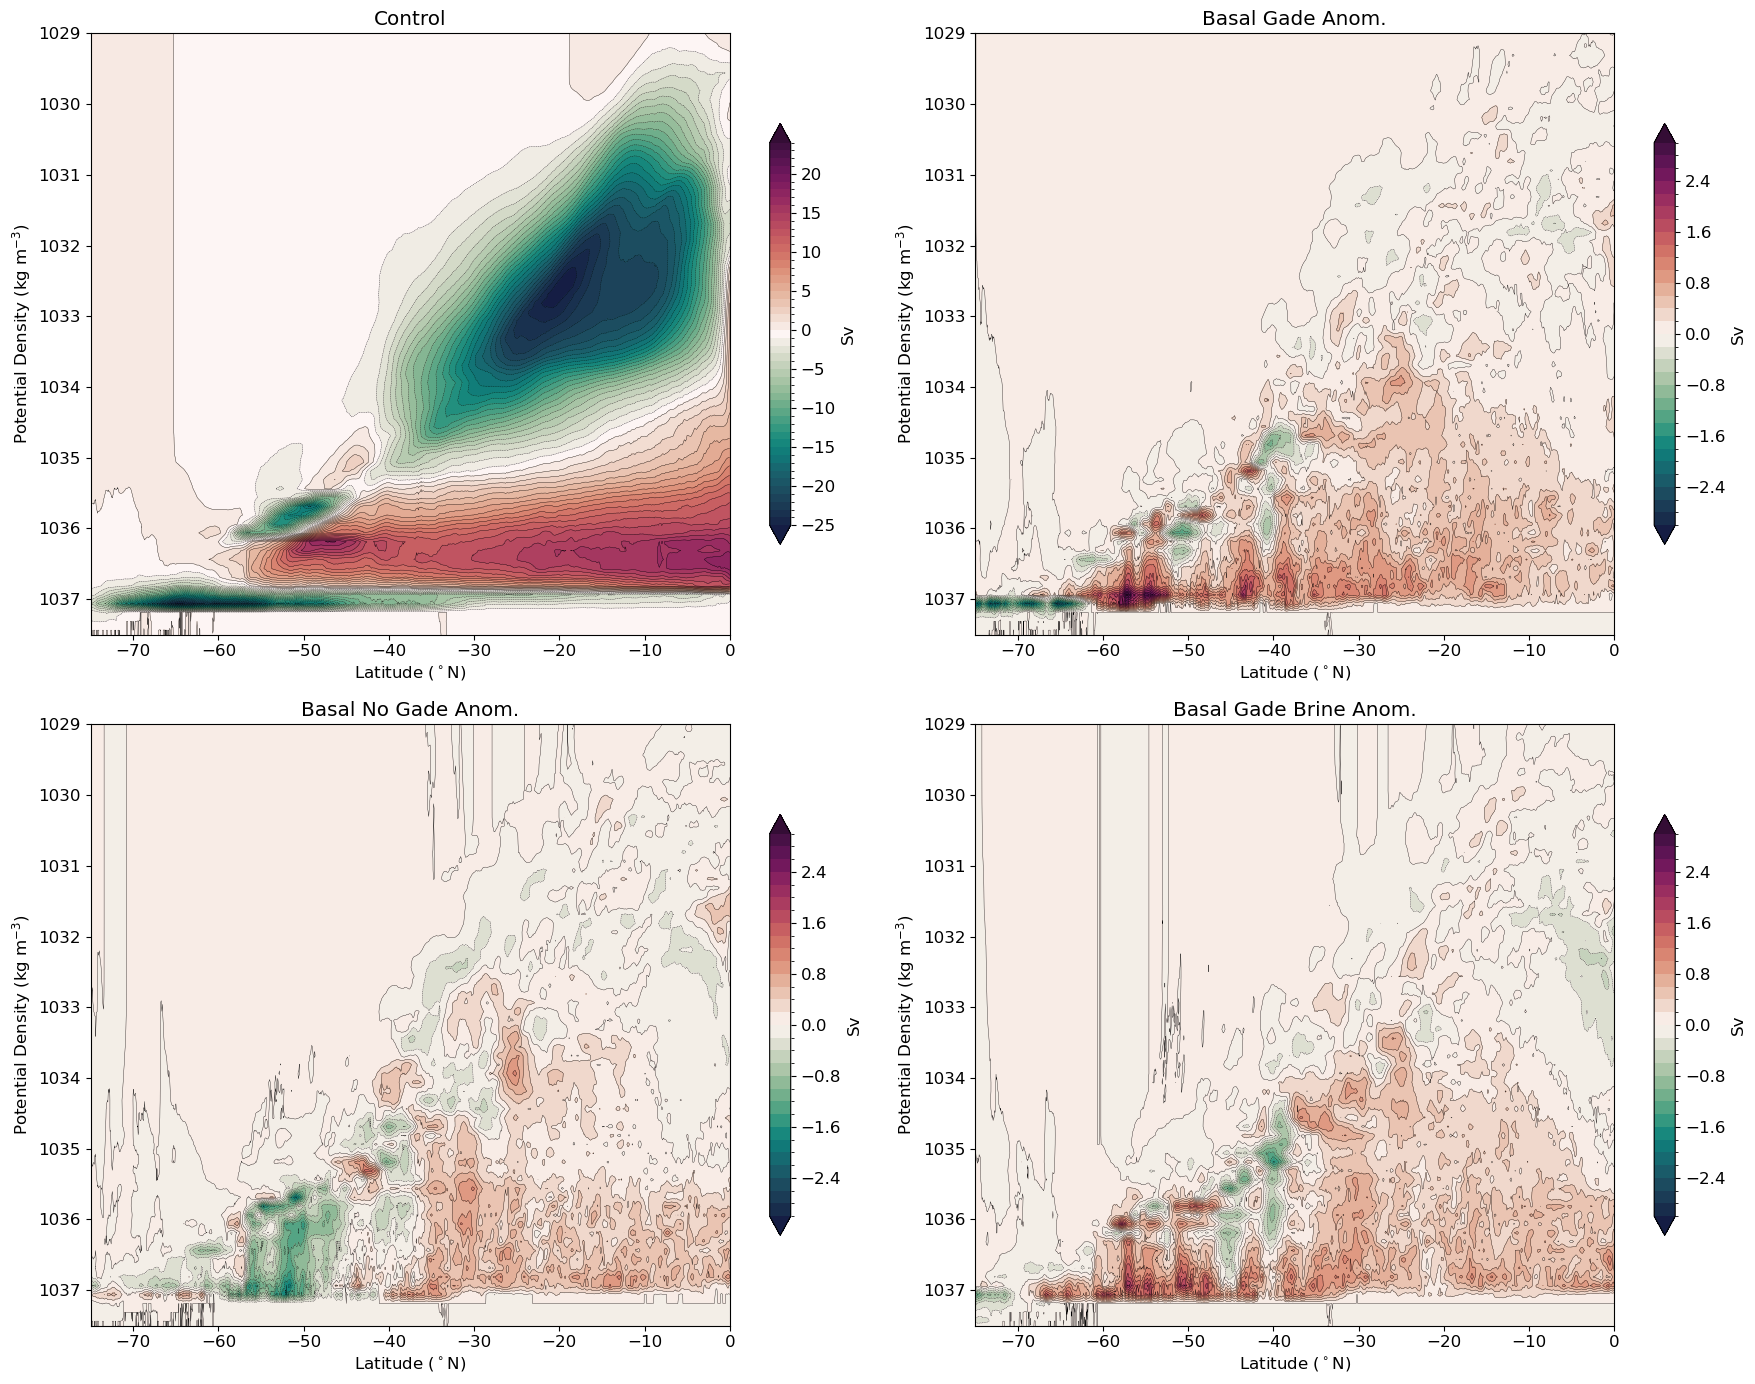

In [12]:
plt.rcParams['font.size'] = 12
fig, axes = plt.subplots(4,2, figsize=(18,14))
plt.subplots_adjust(wspace=0.05, hspace=0.06)

#plt.figure(figsize(12.5,12.5))
#x_formatter = matplotlib.ticker.ScalarFormatter(useOffset=False)
#max_psi = 1 # Sv
#levels, cbarticks = levels_and_colorbarticks(max_psi)

c_psi_avg=c_psi[7:10,:,:].mean(dim="time").load()

plt.subplot(2,2,1)
clev = np.arange(-25,25,1)

c_psi_avg.plot.contourf(levels=clev,
                        cmap=cm.cm.curl,
                        extend='both',
                        cbar_kwargs={'shrink': 0.7, 'label': 'Sv'})

c_psi_avg.plot.contour(levels=clev,
                     colors='k',
                     linewidths=0.25)

plt.gca().invert_yaxis()

plt.ylim((1037.5, 1029))
plt.ylabel('Potential Density (kg m$^{-3}$)')
plt.xlabel('Latitude ($^\circ$N)')
plt.xlim([-75, 0])
plt.title(f'Control');


plt.subplot(2,2,2)
clev = np.arange(-3,3.2,.2)

bg_psi_avg=bg_psi[7:10,:,:].mean(dim="time").load()-c_psi_avg

bg_psi_avg.plot.contourf(levels=clev,
                      cmap=cm.cm.curl,
                        extend='both',
                        cbar_kwargs={'shrink': 0.7, 'label': 'Sv'})

bg_psi_avg.plot.contour(levels=clev,
                     colors='k',
                     linewidths=0.25)

plt.gca().invert_yaxis()

plt.ylim((1037.5, 1029))
plt.ylabel('Potential Density (kg m$^{-3}$)')
plt.xlabel('Latitude ($^\circ$N)')
plt.xlim([-75, 0])
plt.title(f'Basal Gade Anom.');


plt.subplot(2,2,3)

bng_psi_avg=bng_psi[7:10,:,:].mean(dim="time").load()-c_psi_avg

bng_psi_avg.plot.contourf(levels=clev,
                      cmap=cm.cm.curl,
                        extend='both',
                        cbar_kwargs={'shrink': 0.7, 'label': 'Sv'})

bng_psi_avg.plot.contour(levels=clev,
                     colors='k',
                     linewidths=0.25)

plt.gca().invert_yaxis()

plt.ylim((1037.5, 1029))
plt.ylabel('Potential Density (kg m$^{-3}$)')
plt.xlabel('Latitude ($^\circ$N)')
plt.xlim([-75, 0])
plt.title(f'Basal No Gade Anom.');

plt.subplot(2,2,4)
bgb_psi_avg=bgb_psi[7:10,:,:].mean(dim="time").load()-c_psi_avg

bgb_psi_avg.plot.contourf(levels=clev,
                      cmap=cm.cm.curl,
                        extend='both',
                        cbar_kwargs={'shrink': 0.7, 'label': 'Sv'})

bgb_psi_avg.plot.contour(levels=clev,
                     colors='k',
                     linewidths=0.25)

plt.gca().invert_yaxis()

plt.ylim((1037.5, 1029))
plt.ylabel('Potential Density (kg m$^{-3}$)')
plt.xlabel('Latitude ($^\circ$N)')
plt.xlim([-75, 0])
plt.title(f'Basal Gade Brine Anom.');

plt.tight_layout()

In [33]:
#calculate barotropic stream function
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,0)

# the reference density
ρ0 = 1035 * ureg.kilogram / ureg.meter**3
variable='tx_trans_int_z'

mass_transport = cc.querying.getvar(control, variable, master_session, 
                                        start_time = start_time,
                                        end_time = end_time,
                                        frequency = '1 monthly',
                                        chunks = {'time':3})
    
# ensure we get the time-slice we wanted
mass_transport = mass_transport.sel(time = slice(start_time, end_time)).resample(time="Y").mean(dim='time')
        
volume_transport = mass_transport / ρ0

c_bt = volume_transport.cf.cumsum('latitude').load()
    
c_bt.to_netcdf('/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/control_gade_psi.nc')

In [35]:
#calculate barotropic stream function
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,0)

# the reference density
ρ0 = 1035 * ureg.kilogram / ureg.meter**3
variable='tx_trans_int_z'

mass_transport = cc.querying.getvar(basal_gade, variable, basal_melt_session, 
                                        start_time = start_time,
                                        end_time = end_time,
                                        frequency = '1 monthly',
                                        chunks = {'time':3})
    
# ensure we get the time-slice we wanted
mass_transport = mass_transport.sel(time = slice(start_time, end_time)).resample(time="Y").mean(dim='time')
        
volume_transport = mass_transport / ρ0

bg_bt = volume_transport.cf.cumsum('latitude').load()
bg_bt.to_netcdf('/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_psi.nc')

In [36]:
#calculate barotropic stream function
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,0)

# the reference density
ρ0 = 1035 * ureg.kilogram / ureg.meter**3
variable='tx_trans_int_z'

mass_transport = cc.querying.getvar(basal_nogade, variable, basal_melt_session, 
                                        start_time = start_time,
                                        end_time = end_time,
                                        frequency = '1 monthly',
                                        chunks = {'time':3})
    
# ensure we get the time-slice we wanted
mass_transport = mass_transport.sel(time = slice(start_time, end_time)).resample(time="Y").mean(dim='time')
    
volume_transport = mass_transport / ρ0

bng_bt = volume_transport.cf.cumsum('latitude').load()
bng_bt.to_netcdf('/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_nogade_psi.nc')

In [37]:
#calculate barotropic stream function
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,0)

# the reference density
ρ0 = 1035 * ureg.kilogram / ureg.meter**3
variable='tx_trans_int_z'

mass_transport = cc.querying.getvar(basal_gade_brine, variable, basal_melt_session, 
                                        start_time = start_time,
                                        end_time = end_time,
                                        frequency = '1 monthly',
                                        chunks = {'time':3})
    
# ensure we get the time-slice we wanted
mass_transport = mass_transport.sel(time = slice(start_time, end_time)).resample(time="Y").mean(dim='time')
    
volume_transport = mass_transport / ρ0

bgb_bt = volume_transport.cf.cumsum('latitude').load()
bgb_bt.to_netcdf('/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_brine_psi.nc')

In [5]:
ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/control_gade_psi.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
c_bt = ds.tx_trans_int_z.load()


ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_psi.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
bg_bt = ds.tx_trans_int_z.load()

#ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_icb_psi.nc'
#ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
#bgicb_bt = ds.tx_trans_int_z.load()

ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_nogade_psi.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
bng_bt = ds.tx_trans_int_z.load()
 
ifile ='/home/561/pas561/gdjk72/basal_mom5-collaborative-project/notebooks/transports/basal_gade_brine_psi.nc'
ds = xr.open_dataset(ifile, mode='r') # file handle, open in read only mode
bgb_bt = ds.tx_trans_int_z.load()


In [6]:
ds

<xarray.Dataset>
Dimensions:         (yt_ocean: 2700, xu_ocean: 3600, time: 11)
Coordinates:
  * yt_ocean        (yt_ocean) float64 -81.11 -81.07 -81.02 ... 89.94 89.98
  * xu_ocean        (xu_ocean) float64 -279.9 -279.8 -279.7 ... 79.8 79.9 80.0
  * time            (time) object 1900-12-31 00:00:00 ... 1910-12-31 00:00:00
Data variables:
    tx_trans_int_z  (time, yt_ocean, xu_ocean) float32 0.0 0.0 ... 1.421e+08

In [7]:
print(c_bt.shape)
print(bg_bt.shape)
print(bng_bt.shape)
print(bgb_bt.shape)

(11, 2700, 3600)
(11, 2700, 3600)
(10, 2700, 3600)
(11, 2700, 3600)


In [26]:
c_bt

<xarray.DataArray 'tx_trans_int_z' (time: 11, yt_ocean: 2700, xu_ocean: 3600)>
array([[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [1.5355338e+08, 1.5355293e+08, 1.5355290e+08, ...,
         1.5355390e+08, 1.5355368e+08, 1.5355362e+08],
        [1.5355338e+08, 1.5355293e+08, 1.5355290e+08, ...,
         1.5355390e+08, 1.5355368e+08, 1.5355362e+08],
        [1.5355338e+08, 1.5355293e+08, 1.5355290e+08, ...,
         1.5355390e+08, 1.5355368e+08, 1.5355362e+08]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
...
        [1.3970259e+08, 1.3970269e+08, 1.3970272e+08, ...,
         1.3970256e+08, 1.3970282e+08, 1.3970283e+08],
        [1.3970259e+08, 1.3970269e+08, 1.3970272e+08, ...,
         1.3970256e+08, 1.3970282e+08, 1.3970283e+08],
        [1.3970259e+08, 1.3970269e+08, 1.3970272e+08, ...,
         1.3970256e+08, 1.3970282e+08, 1.3970283e+08]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [1.3831006e+08, 1.3831014e+08, 1.3831037e+08, ...,
         1.3831026e+08, 1.3831024e+08, 1.3831034e+08],
        [1.3831006e+08, 1.3831014e+08, 1.3831037e+08, ...,
         1.3831026e+08, 1.3831024e+08, 1.3831034e+08],
        [1.3831006e+08, 1.3831014e+08, 1.3831037e+08, ...,
         1.3831026e+08, 1.3831024e+08, 1.3831034e+08]]], dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xu_ocean  (xu_ocean) float64 -279.9 -279.8 -279.7 -279.6 ... 79.8 79.9 80.0
  * time      (time) object 1900-12-31 00:00:00 ... 1910-12-31 00:00:00

In [8]:
straits = {'Drake Passage': [ -69.9,  -69.9, -71.6, -51.0],
           'Lombok':        [-244.6, -243.9,  -8.6,  -8.6],
           'Ombai' :        [-235.0, -235.0,  -9.2,  -8.1],
           'Timor' :        [-235.9, -235.9, -11.9,  -9.9],
           'Denmark' :      [ -42.0,  -22.0,  65.8,  65.8],
           'Bering' :       [-172.0, -167.0,  65.8,  65.8],
           }

In [9]:
xmin, xmax, ymin, ymax = straits['Drake Passage']
print(xmin,xmax,ymin,ymax)

-69.9 -69.9 -71.6 -51.0


In [35]:
dp_c_bt = c_bt.cf.sel(longitude=xmin, method='nearest').cf.sel(latitude=slice(ymin, ymax)).max(dim='yt_ocean')/1E6
dp_bg_bt = bg_bt.cf.sel(longitude=xmin, method='nearest').cf.sel(latitude=slice(ymin, ymax)).max(dim='yt_ocean')/1E6
dp_bng_bt = bng_bt.cf.sel(longitude=xmin, method='nearest').cf.sel(latitude=slice(ymin, ymax)).max(dim='yt_ocean')/1E6
dp_bgb_bt = bgb_bt.cf.sel(longitude=xmin, method='nearest').cf.sel(latitude=slice(ymin, ymax)).max(dim='yt_ocean')/1E6

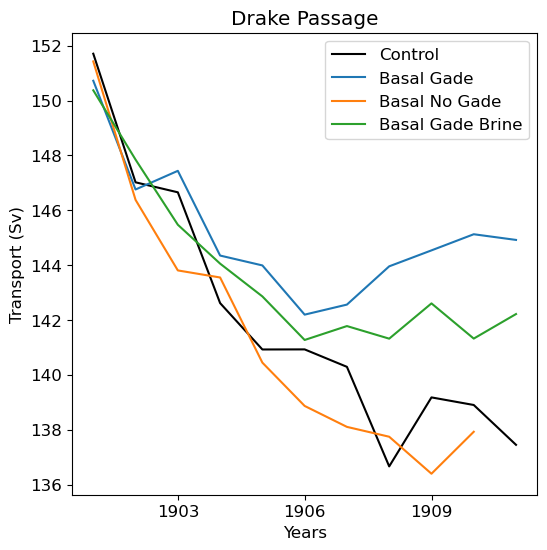

In [52]:
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize = (6, 6))
dp_c_bt.plot.line(x='time',label='Control',color='k')
dp_bg_bt.plot.line(x='time',label='Basal Gade')
dp_bng_bt.plot.line(x='time',label='Basal No Gade')
dp_bgb_bt.plot.line(x='time',label='Basal Gade Brine')

plt.title('Drake Passage')
plt.ylabel('Transport (Sv)')
plt.xlabel('Years')
plt.legend()

In [23]:
c_bt_avg=c_bt[7:10,:,:].mean(dim="time").load()/1E6
bg_bt_avg=bg_bt[7:10,:,:].mean(dim="time").load()/1E6
bng_bt_avg=bng_bt[7:10,:,:].mean(dim="time").load()/1E6
bgb_bt_avg=bgb_bt[7:10,:,:].mean(dim="time").load()/1E6


In [24]:
axes[0]

NameError: name 'axes' is not defined

Text(0.5, 1.0, 'Control')

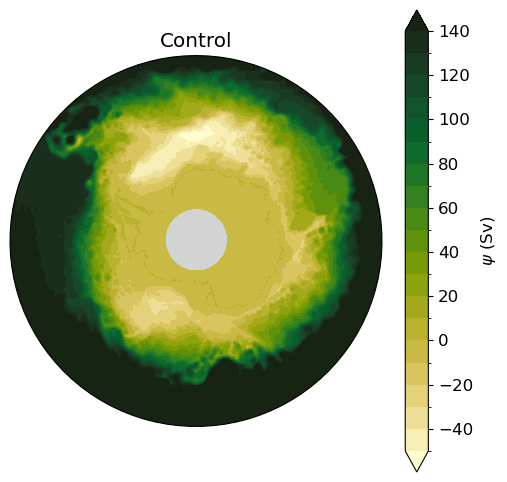

In [25]:
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize = (6, 6))
#fig, axes = plt.subplots(4,2, figsize=(18,14))
#plt.subplots_adjust(wspace=0.05, hspace=0.06)

ax = plt.axes(projection = ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -80, -40], crs = ccrs.PlateCarree())
ax.set_facecolor('lightgrey')
# Map the plot boundaries to a circle
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)


#plt.subplot(2,2,1)
clev = np.arange(-50,150,10)

c_bt_avg.plot.contourf(ax = ax,
                                   x = 'xu_ocean',
                                   y = 'yt_ocean', 
                                   transform = ccrs.PlateCarree(),
                                   levels = clev,
                                   extend = 'both',
                                   cmap = cm.cm.speed,
                                   cbar_kwargs = {'label': '$\psi$ (Sv)'})
plt.title('Control')

Text(0.5, 1.0, 'Basal Gade Anom.')

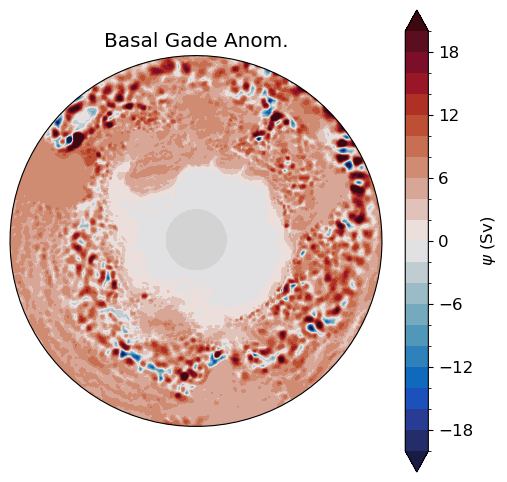

In [107]:
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize = (6, 6))
#fig, axes = plt.subplots(4,2, figsize=(18,14))
#plt.subplots_adjust(wspace=0.05, hspace=0.06)

ax = plt.axes(projection = ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -80, -40], crs = ccrs.PlateCarree())
ax.set_facecolor('lightgrey')
# Map the plot boundaries to a circle
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)

anom=bg_bt_avg-c_bt_avg
#plt.subplot(2,2,1)
clev = np.arange(-20,22,2)

anom.plot.contourf(ax = ax,
                                   x = 'xu_ocean',
                                   y = 'yt_ocean', 
                                   transform = ccrs.PlateCarree(),
                                   levels = clev,
                                   extend = 'both',
                                   cmap = cm.cm.balance,
                                   cbar_kwargs = {'label': '$\psi$ (Sv)'})
plt.title('Basal Gade Anom.')

In [108]:
clev

array([-20, -18, -16, -14, -12, -10,  -8,  -6,  -4,  -2,   0,   2,   4,
         6,   8,  10,  12,  14,  16,  18,  20])

Text(0.5, 1.0, 'Basal No Gade Anom.')

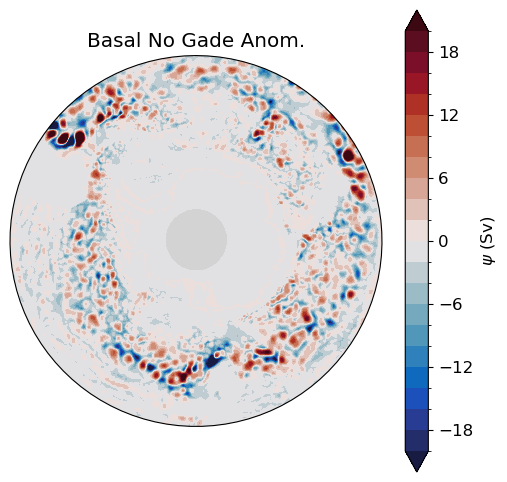

In [111]:
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize = (6, 6))
#fig, axes = plt.subplots(4,2, figsize=(18,14))
#plt.subplots_adjust(wspace=0.05, hspace=0.06)

ax = plt.axes(projection = ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -80, -40], crs = ccrs.PlateCarree())
ax.set_facecolor('lightgrey')
# Map the plot boundaries to a circle
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)

anom=bng_bt_avg-c_bt_avg
#plt.subplot(2,2,1)
clev = np.arange(-20,22,2)

anom.plot.contourf(ax = ax,
                                   x = 'xu_ocean',
                                   y = 'yt_ocean', 
                                   transform = ccrs.PlateCarree(),
                                   levels = clev,
                                   extend = 'both',
                                   cmap = cm.cm.balance,
                                   cbar_kwargs = {'label': '$\psi$ (Sv)'})
plt.title('Basal No Gade Anom.')

Text(0.5, 1.0, 'Basal Gade Brine Anom.')

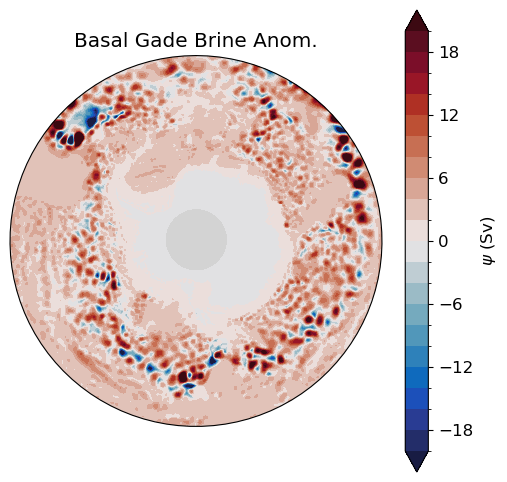

In [112]:
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize = (6, 6))
#fig, axes = plt.subplots(4,2, figsize=(18,14))
#plt.subplots_adjust(wspace=0.05, hspace=0.06)

ax = plt.axes(projection = ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -80, -40], crs = ccrs.PlateCarree())
ax.set_facecolor('lightgrey')
# Map the plot boundaries to a circle
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)

anom=bgb_bt_avg-c_bt_avg
#plt.subplot(2,2,1)
clev = np.arange(-20,22,2)

anom.plot.contourf(ax = ax,
                                   x = 'xu_ocean',
                                   y = 'yt_ocean', 
                                   transform = ccrs.PlateCarree(),
                                   levels = clev,
                                   extend = 'both',
                                   cmap = cm.cm.balance,
                                   cbar_kwargs = {'label': '$\psi$ (Sv)'})
plt.title('Basal Gade Brine Anom.')

Text(0.5, 1.0, 'Basal Gade Brine - No Basal Gade Anom.')

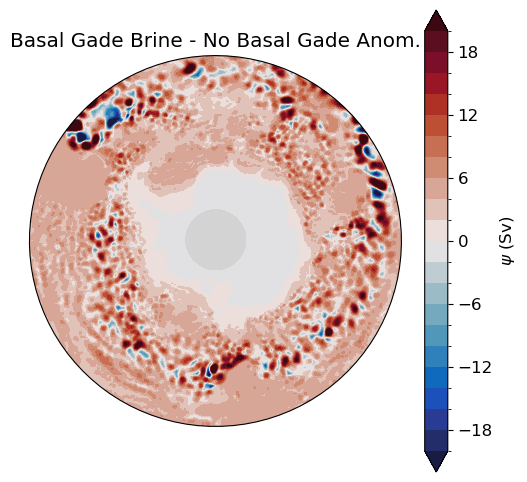

In [113]:
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize = (6, 6))
#fig, axes = plt.subplots(4,2, figsize=(18,14))
#plt.subplots_adjust(wspace=0.05, hspace=0.06)

ax = plt.axes(projection = ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -80, -40], crs = ccrs.PlateCarree())
ax.set_facecolor('lightgrey')
# Map the plot boundaries to a circle
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)

anom=bgb_bt_avg-bng_bt_avg
#plt.subplot(2,2,1)
clev = np.arange(-20,22,2)

anom.plot.contourf(ax = ax,
                                   x = 'xu_ocean',
                                   y = 'yt_ocean', 
                                   transform = ccrs.PlateCarree(),
                                   levels = clev,
                                   extend = 'both',
                                   cmap = cm.cm.balance,
                                   cbar_kwargs = {'label': '$\psi$ (Sv)'})
plt.title('Basal Gade Brine - No Basal Gade Anom.')

In [66]:
def circumpolar_map():
    fig = plt.figure(figsize = (12, 8))
    ax = plt.axes(projection = ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -80, -40], crs = ccrs.PlateCarree())
    ax.set_facecolor('lightgrey')
    # Map the plot boundaries to a circle
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)

    return fig, ax

In [ ]:
for model in ['mom5', 'mom6']:

    fig, ax = circumpolar_map()

    ψ_mean[model].cf.plot.contourf(ax = ax,
                                   x = 'longitude',
                                   y = 'latitude', 
                                   transform = ccrs.PlateCarree(),
                                   levels = levels,
                                   extend = 'both',
                                   cmap = cmocean.cm.speed,
                                   cbar_kwargs = {'label': '$\psi$ (Sv)'})
    land_mask[model].plot.contourf(ax = ax, colors = 'lightgrey', add_colorbar = False, 
                                   zorder = 2, transform = ccrs.PlateCarree())

    plt.title('Barotropic streamfunction from ' + model)